# Fetal ECG Analysis and Extraction
Pipeline implementation based on *A robust fetal ECG detection method for abdominal recordings* (Martens et al., 2007).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
from scipy import signal
import wfdb
import glob
from sklearn.decomposition import FastICA

sys.path.append(os.path.abspath('../src'))
from filtering import BaselineWanderRemover, AdaptivePLICanceller
from preprocessing import SignalResampler
from mecg_canceller import MECGCanceller
from fecg_extractor import FECGExtractor
from utils import (compute_fhr, compute_fhr_reliability, compute_success_rate,
                   load_ground_truth_peaks, match_peaks_to_gt, precision_recall_f1)

from plotting import (plot_qrs_detection_dual, plot_pipeline_stages, plot_ica_stages,
                      plot_fhr_traces, plot_performance_summary, plot_detection_validation,
                      plot_ground_truth_validation, plot_filter_transfer_function,
                      plot_before_after_comprehensive)

## 1. Data Loading and Preprocessing

In [2]:
data_dir = '../data/set_a/'
hea_files = glob.glob(os.path.join(data_dir, '*.hea'))
record_names = [os.path.splitext(os.path.basename(f))[0] for f in hea_files]
record_names.sort()

# samples (~100 ms at 1000 Hz). 100 samples is the maximum gap size that will be interpolated. 
# Gaps larger than this will remain NaN.
INTERP_LIMIT = 100 

all_records_data = {}
for record_name in record_names:
    data_path = os.path.join(data_dir, record_name)
    record = wfdb.rdrecord(data_path)
    fs_original = record.fs
    
    df = pd.DataFrame(record.p_signal)
    n_nans = df.isnull().values.sum()
    if n_nans > 0:
        nan_channels = list(df.columns[df.isnull().any()])
        print(f"{record_name}: {n_nans} NaN samples found in channel(s) {nan_channels}, interpolating.")
        df = df.interpolate(method='linear', limit=INTERP_LIMIT, limit_direction='both')
        if df.isnull().values.any():
            print(f"WARNING: {record_name} still has {df.isnull().values.sum()} unfilled NaN samples "
                  f"(gap larger than limit={INTERP_LIMIT}).")
        clean_signal = df.values
    else:
        clean_signal = record.p_signal

    all_records_data[record_name] = {'signal': clean_signal, 'fs': fs_original}

target_record = 'a22'
raw_signal = all_records_data[target_record]['signal']
fs_orig = all_records_data[target_record]['fs']

a01: 18 NaN samples found in channel(s) [1], interpolating.
a02: 115 NaN samples found in channel(s) [1], interpolating.
a07: 9 NaN samples found in channel(s) [1], interpolating.
a09: 97 NaN samples found in channel(s) [1], interpolating.
a11: 108 NaN samples found in channel(s) [1], interpolating.
a16: 109 NaN samples found in channel(s) [1], interpolating.
a18: 300 NaN samples found in channel(s) [1], interpolating.


## 2. Pipeline Execution & Visualisation

In [3]:
# 1. Baseline Wander Removal (S1 -> S2)
# Applying filters using the original sampling frequency (fs_orig) -- 1000Hz in this case
bwr = BaselineWanderRemover(fs=fs_orig)

s1_signal = raw_signal
s2_signal = np.zeros_like(s1_signal)
for ch in range(s1_signal.shape[1]):
    s2_signal[:, ch] = bwr.apply(s1_signal[:, ch])

plot_offset_s = 6.5
plot_samples_orig = int(fs_orig * 3.0) 
plot_offset_orig = int(plot_offset_s * fs_orig)
t_orig = np.arange(plot_samples_orig) / fs_orig

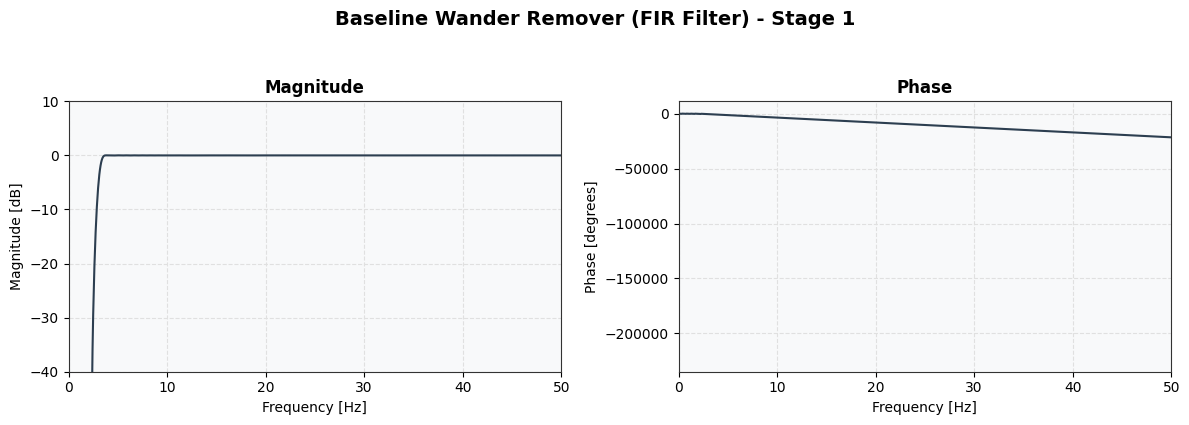

In [4]:
plot_filter_transfer_function(bwr.taps, [1.0], fs_orig, title="Baseline Wander Remover (FIR Filter) - Stage 1")

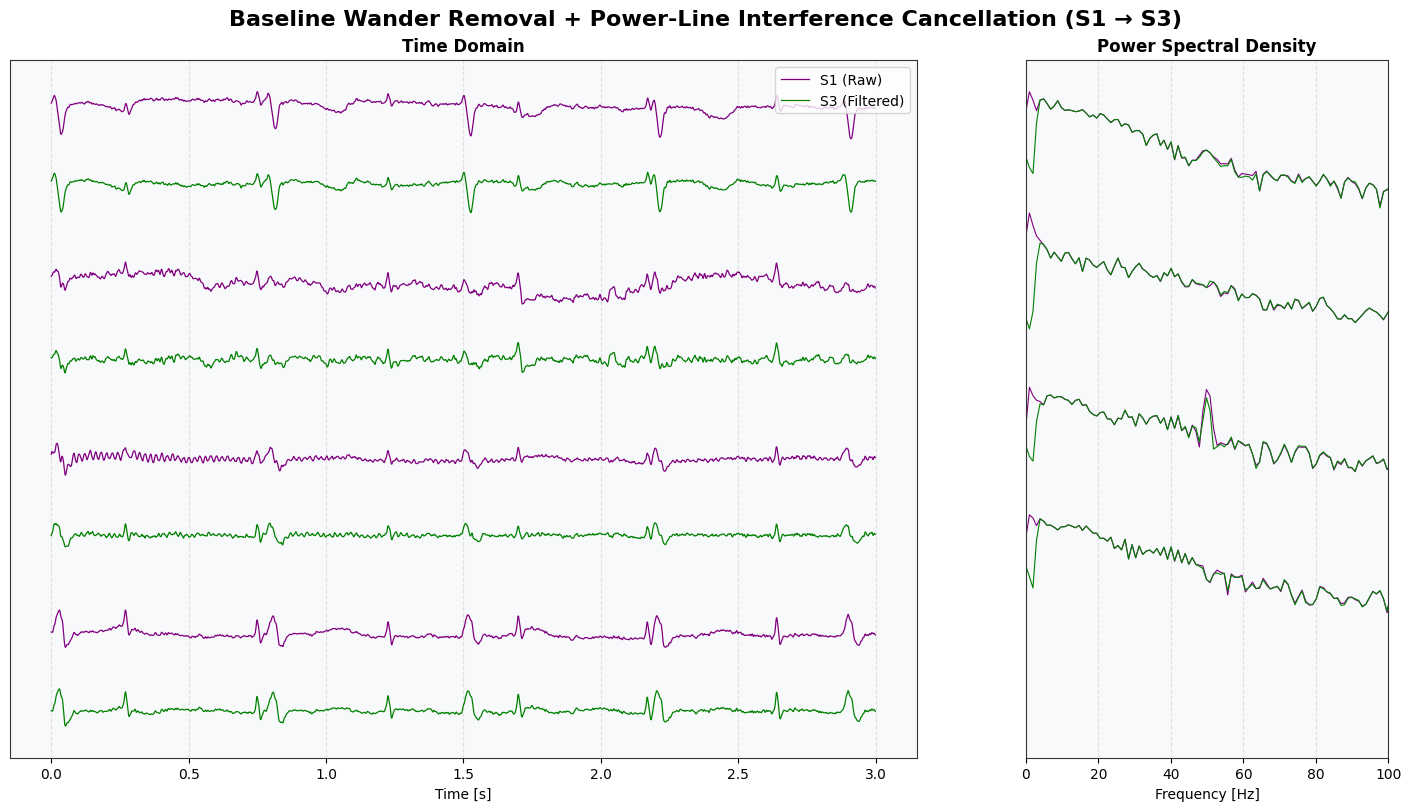

In [5]:
# 2. Power-Line Interference Cancellation (S2 -> S3)
plc = AdaptivePLICanceller(fs=fs_orig)

s3_signal = np.zeros_like(s2_signal)
for ch in range(s2_signal.shape[1]):
    s3_signal[:, ch] = plc.apply(s2_signal[:, ch])

# BWR + PLC (S1 -> S3) plotting
plot_before_after_comprehensive(t_orig, s1_signal[plot_offset_orig:plot_offset_orig+plot_samples_orig, :],
                           s3_signal[plot_offset_orig:plot_offset_orig+plot_samples_orig, :], fs_orig,
                           title="Baseline Wander Removal + Power-Line Interference Cancellation (S1 → S3)")

In [6]:
# 3. Upsampling to 2000Hz (S4)
fs_target = 2000.0
resampler = SignalResampler(original_fs=fs_orig, target_fs=fs_target)
s4_signal = resampler.upsample(s3_signal.T).T

plot_offset_target = int(plot_offset_s * fs_target)

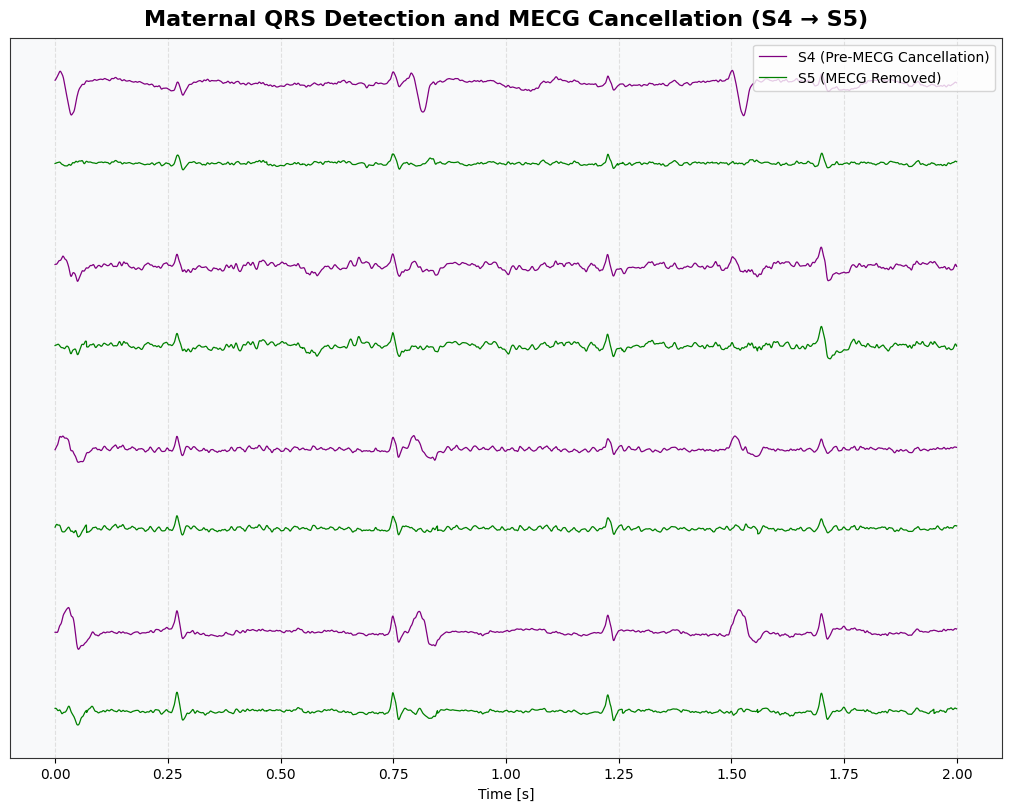

In [7]:
# 4. Maternal QRS Detection and MECG Cancellation (S4 -> S5)
mecg_canc = MECGCanceller(fs=fs_target)
s5_signal = mecg_canc.apply(s4_signal)

plot_samples_2s = int(fs_target * 2.0) 
t_2s = np.arange(plot_samples_2s) / fs_target

plot_before_after_comprehensive(t_2s, s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                           s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :], fs_target,
                           title="Maternal QRS Detection and MECG Cancellation (S4 → S5)",
                           before_label="S4 (Pre-MECG Cancellation)", after_label="S5 (MECG Removed)",
                           show_psd=False)

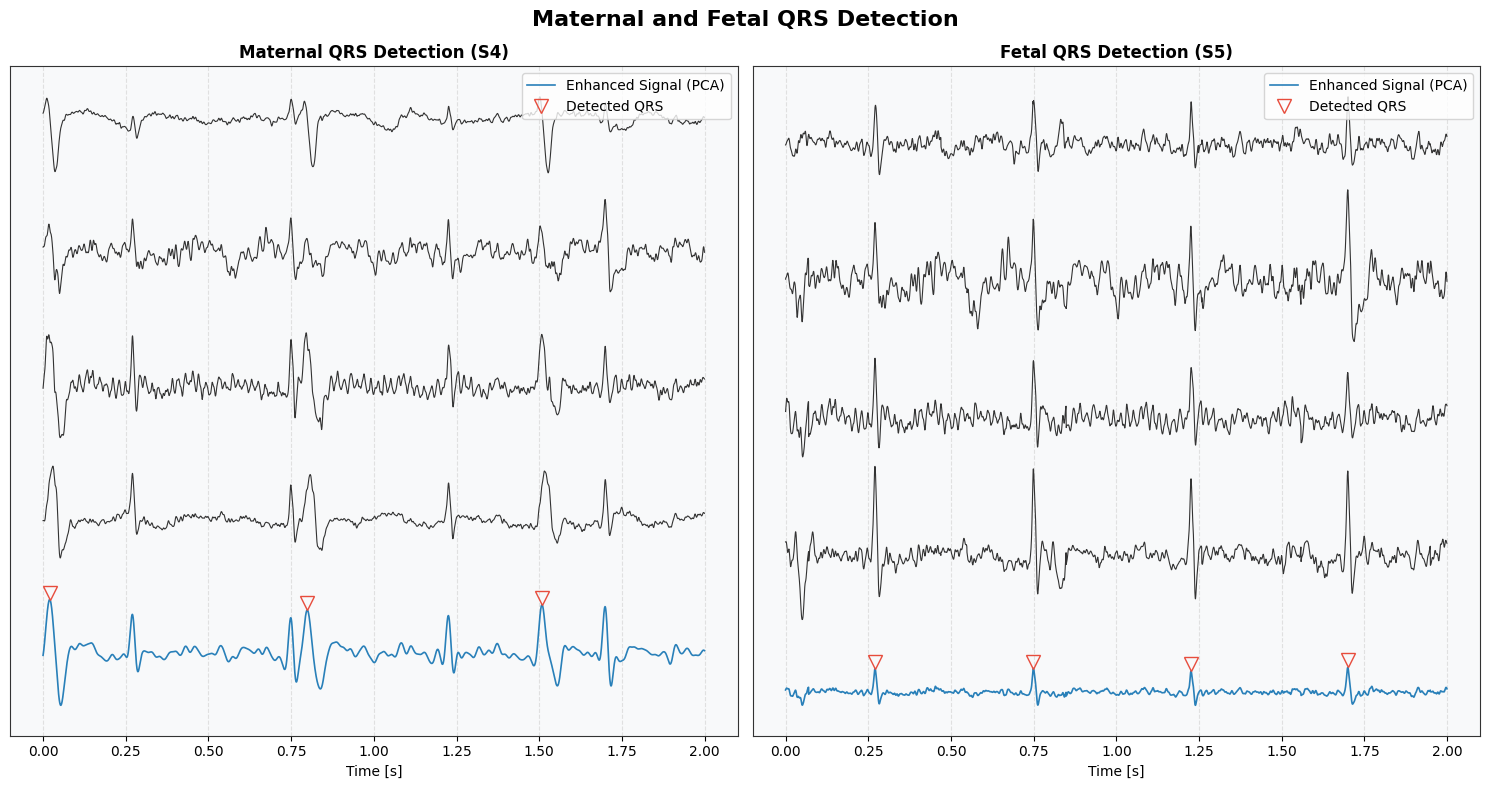

In [8]:
# 5. Maternal QRS Detection (S4) and Fetal QRS Detection / FECG Extraction (S6)
fecg_ext = FECGExtractor(fs=fs_target)

# Multi-channel QRS enhancement (PCA) and fetal QRS detection
fetal_enhanced = fecg_ext.enhance_fetal_qrs(s5_signal)
fetal_peaks = fecg_ext.detect_fetal_qrs(s5_signal)

fetal_peaks_window = fetal_peaks[(fetal_peaks >= plot_offset_target) &
                                  (fetal_peaks < plot_offset_target + plot_samples_2s)] - plot_offset_target

# Multi-channel QRS enhancement (PCA) and maternal QRS detection (on S4, pre-cancellation)
maternal_enhanced = mecg_canc.enhance_maternal_qrs(s4_signal)
maternal_peaks = mecg_canc.detect_maternal_qrs(s4_signal)

maternal_peaks_window = maternal_peaks[(maternal_peaks >= plot_offset_target) &
                                        (maternal_peaks < plot_offset_target + plot_samples_2s)] - plot_offset_target

plot_qrs_detection_dual(t_2s,
                        s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                        maternal_enhanced[plot_offset_target:plot_offset_target+plot_samples_2s],
                        maternal_peaks_window,
                        s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                        fetal_enhanced[plot_offset_target:plot_offset_target+plot_samples_2s],
                        fetal_peaks_window,
                        maternal_title="Maternal QRS Detection (S4)",
                        fetal_title="Fetal QRS Detection (S5)")

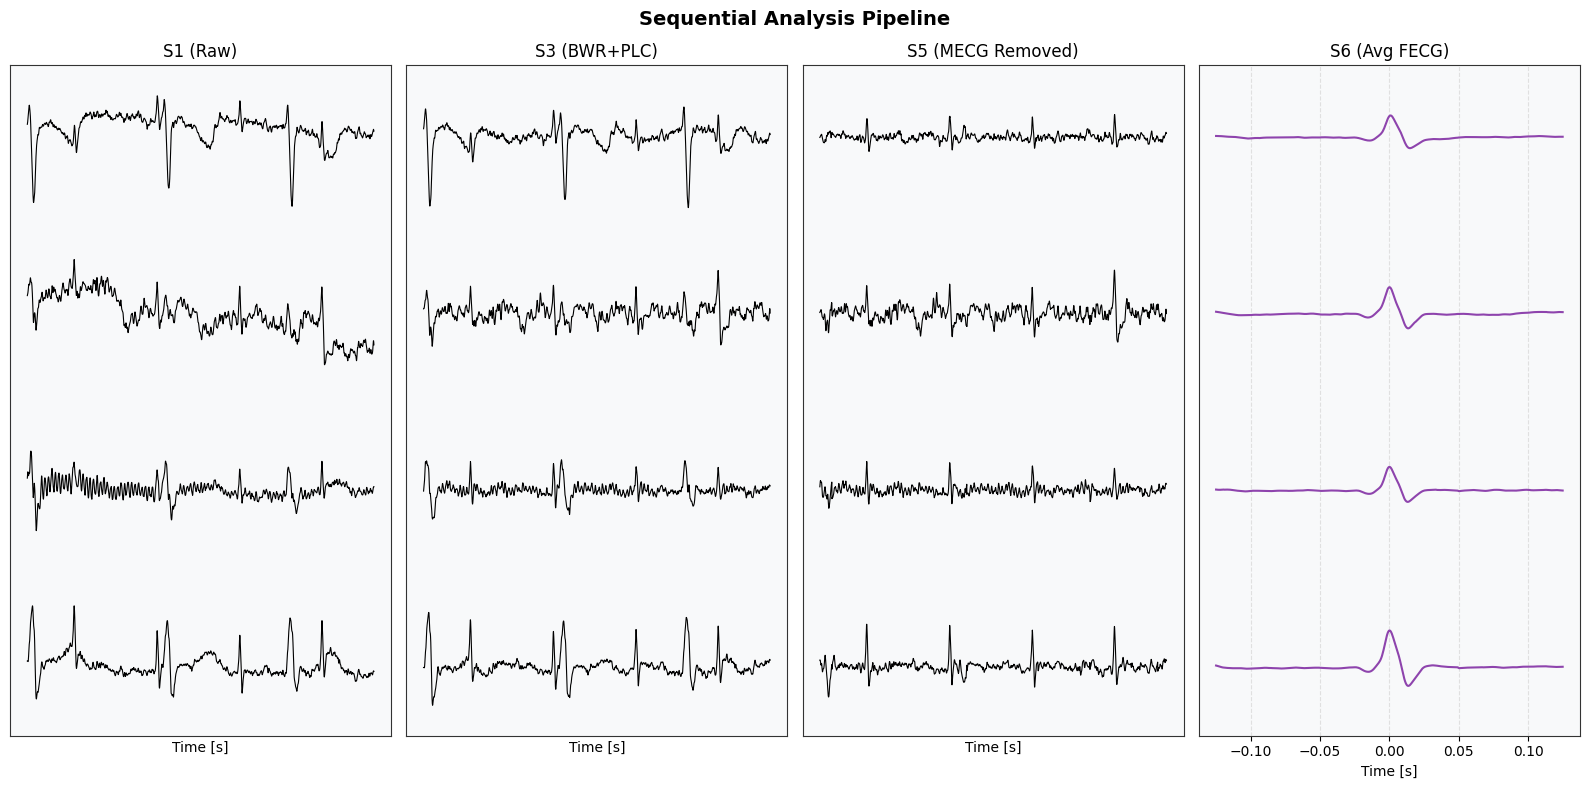

In [9]:
# 6. Synchronous averaging of fetal beats to obtain the average fetal beat morphology (S6)
s6_avg_beat = fecg_ext.synchronous_averaging(s5_signal, fetal_peaks, window_size_sec=0.25)
if s6_avg_beat is None:
    s6_avg_beat = np.zeros((int(0.25 * fs_target), s5_signal.shape[1]))

s1_resampled = resampler.upsample(raw_signal.T).T

plot_pipeline_stages(t_2s, s1_resampled[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s4_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s5_signal[plot_offset_target:plot_offset_target+plot_samples_2s, :],
                     s6_avg_beat)

### Detection Validation Against Ground Truth

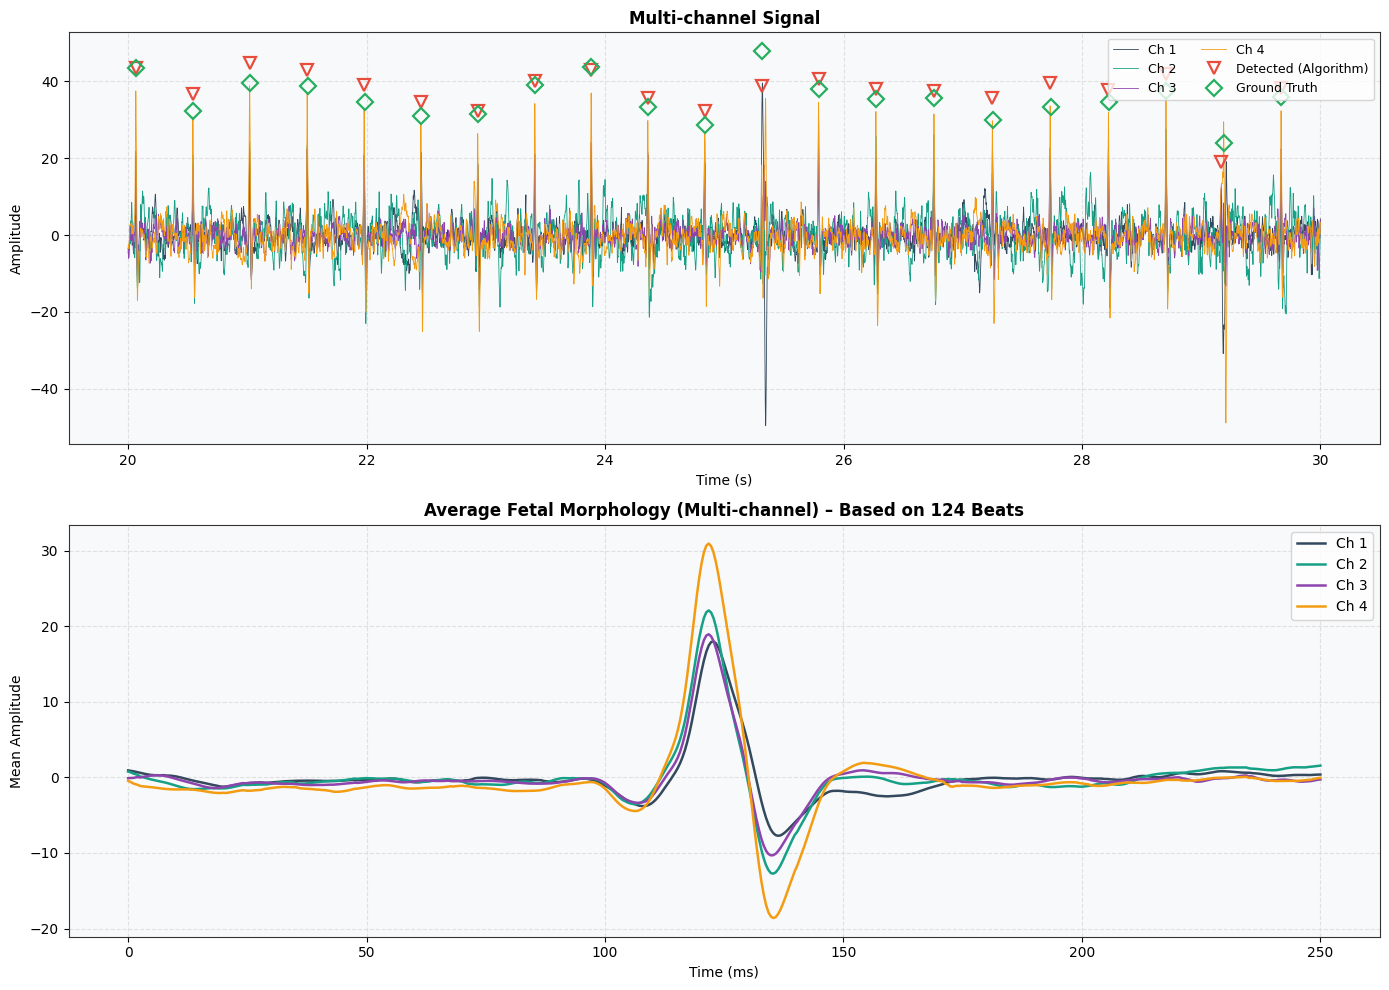

In [10]:
gt_peaks = load_ground_truth_peaks(data_dir, target_record, fs_target)

zoom_start = int(20.0 * fs_target)
zoom_end = int(30.0 * fs_target)
t_zoom = np.arange(zoom_start, zoom_end) / fs_target
channels_zoom = s5_signal[zoom_start:zoom_end, :]

detected_zoom = fetal_peaks[(fetal_peaks >= zoom_start) & (fetal_peaks < zoom_end)] - zoom_start
gt_zoom = gt_peaks[(gt_peaks >= zoom_start) & (gt_peaks < zoom_end)] - zoom_start

half_win = int(0.125 * fs_target)
n_beats_gt = sum(1 for p in gt_peaks if p - half_win >= 0 and p + half_win <= len(s5_signal))
gt_avg_beat = fecg_ext.synchronous_averaging(s5_signal, gt_peaks, window_size_sec=0.25)
if gt_avg_beat is None:
    gt_avg_beat = np.zeros((2 * half_win, s5_signal.shape[1]))
t_avg_ms = np.linspace(0, 250, len(gt_avg_beat))

plot_detection_validation(t_zoom, channels_zoom, detected_zoom, gt_zoom,
                          t_avg_ms, gt_avg_beat, n_beats_gt)

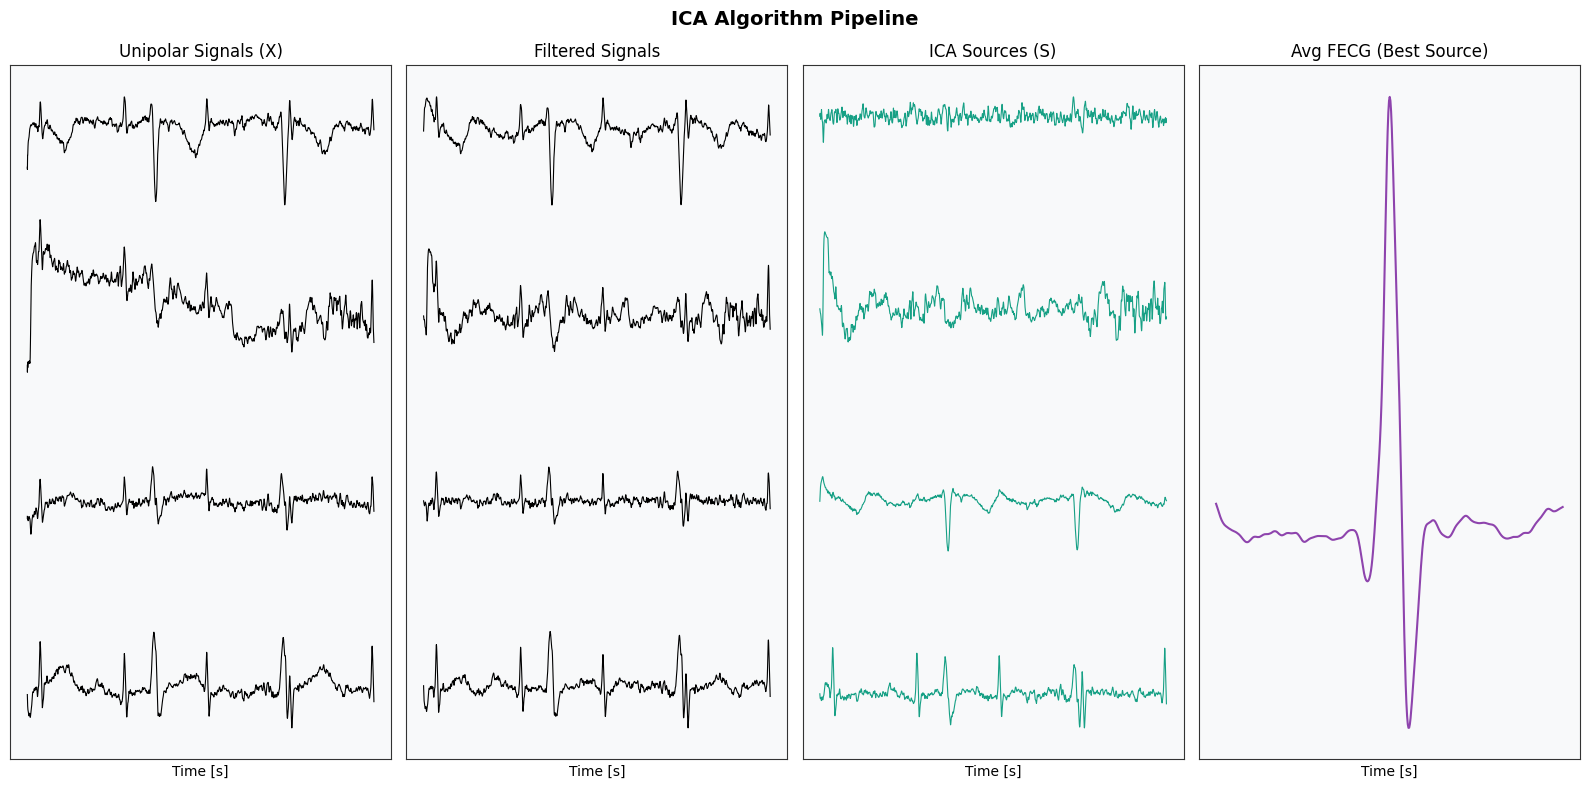

In [11]:
# 7. ICA for FECG Extraction - FastICA to extract fetal ECG components
ica = FastICA(n_components=s4_signal.shape[1], random_state=42, whiten='unit-variance')
ica_sources = ica.fit_transform(s4_signal)

# The QRS detector is applied to every component and the one yielding the most physiologically valid
# FHR points is selected as the best fetal ECG source.
fhr_point_counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(ica_sources[:, i].reshape(-1, 1)), fs_target))
                     for i in range(ica_sources.shape[1])]
best_fecg_idx = int(np.argmax(fhr_point_counts))
best_fecg_source = ica_sources[:, best_fecg_idx].reshape(-1, 1) # single-channel matrix (n_samples, 1)

fetal_peaks_ica = fecg_ext.detect_fetal_qrs(best_fecg_source)
best_fecg_avg = fecg_ext.synchronous_averaging(best_fecg_source, fetal_peaks_ica, window_size_sec=0.25)
if best_fecg_avg is None:
    best_fecg_avg = np.zeros((int(0.25 * fs_target), 1))

plot_ica_stages(t_2s, s1_resampled[:plot_samples_2s, :], 
                 s4_signal[:plot_samples_2s, :], 
                 ica_sources[:plot_samples_2s, :], 
                 best_fecg_avg)

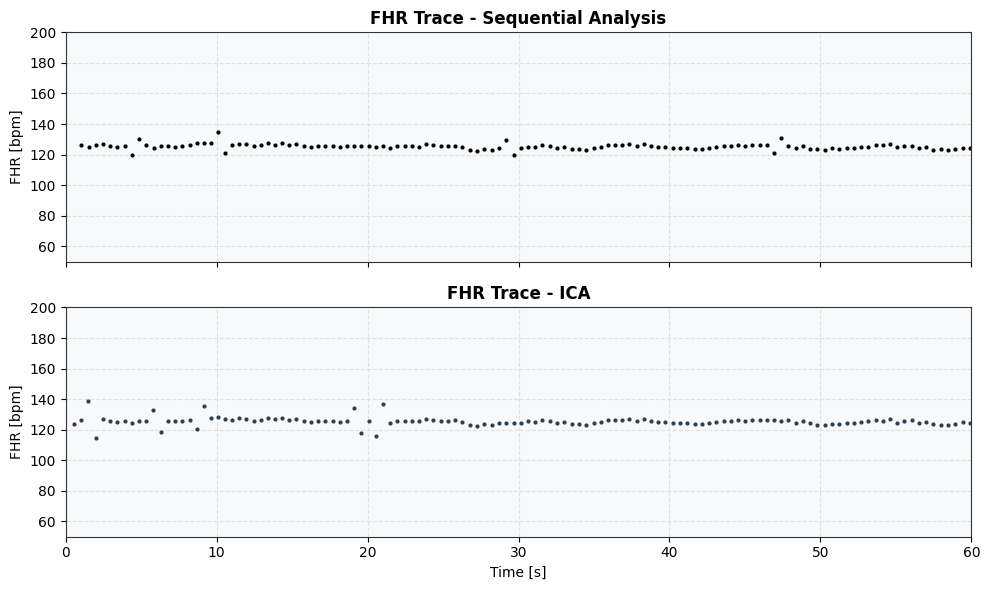

Valid SA points: 124, FHR range: 119.64107676969094 - 134.68013468013467
Valid ICA points: 125, FHR range: 114.7227533460803 - 139.04982618771726


In [12]:
# Compute FHR for SA and ICA over a 60-second window
fs_minutes = int(fs_target * 60.0)

# Limit peaks to the first 60 seconds
peaks_sa_60s = fetal_peaks[fetal_peaks < fs_minutes]
peaks_ica_60s = fetal_peaks_ica[fetal_peaks_ica < fs_minutes]

fhr_sa = compute_fhr(peaks_sa_60s, fs_target)
fhr_ica = compute_fhr(peaks_ica_60s, fs_target)

if len(fhr_sa) > 0 and len(fhr_ica) > 0:
    t_fhr_sa = (peaks_sa_60s[1:] / fs_target)[-len(fhr_sa):]
    t_fhr_ica = (peaks_ica_60s[1:] / fs_target)[-len(fhr_ica):]

    plot_fhr_traces(t_fhr_sa, fhr_sa, t_fhr_ica, fhr_ica)
else:
    print("Insufficient peaks to plot the FHR.")

print(f"Valid SA points: {len(fhr_sa)}, FHR range: {min(fhr_sa) if len(fhr_sa) > 0 else 'N/A'} - {max(fhr_sa) if len(fhr_sa) > 0 else 'N/A'}")
print(f"Valid ICA points: {len(fhr_ica)}, FHR range: {min(fhr_ica) if len(fhr_ica) > 0 else 'N/A'} - {max(fhr_ica) if len(fhr_ica) > 0 else 'N/A'}")

## 3. Performance Measures 

Both the Sequential Analysis pipeline and the FastICA benchmark are re-run per signal (reusing the already-fitted `bwr`, `plc`, `resampler`, `mecg_canc`, `fecg_ext`).

FHR detection success rate -- SA: 100.0%  |  ICA: 100.0%
Mean FHR reliability (feasible patients only) -- SA: 0.736  |  ICA: 0.706


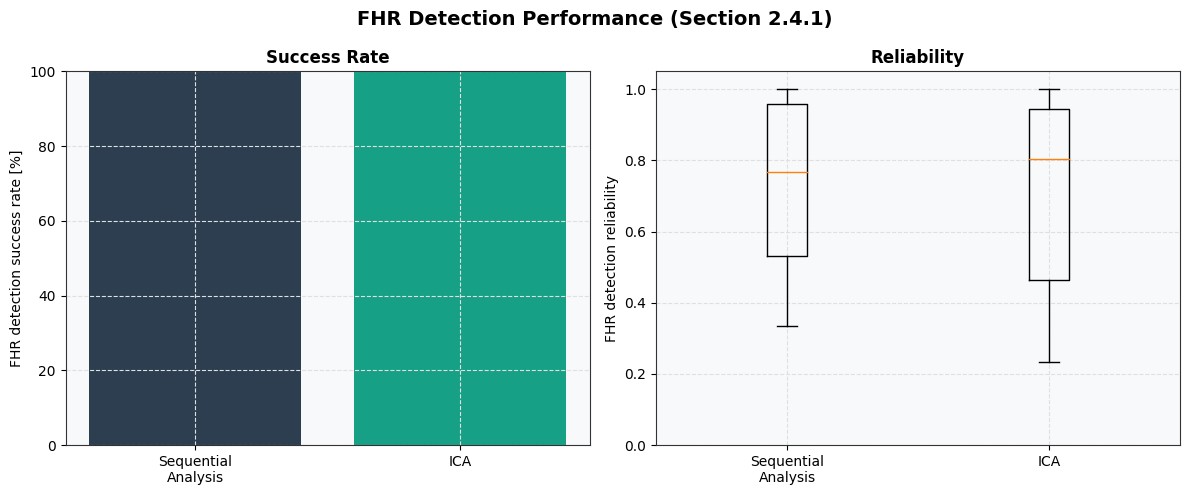

In [13]:
# Performance measures: FHR detection success rate & reliability,
# computed over the full signal set (each record is exactly 60s)
results = []
for record_name, rec_data in all_records_data.items():
    sig, fs_rec = rec_data['signal'], rec_data['fs']

    s1 = sig
    s2 = np.zeros_like(s1)
    for ch in range(s1.shape[1]):
        s2[:, ch] = bwr.apply(s1[:, ch])
    s3 = np.zeros_like(s2)
    for ch in range(s2.shape[1]):
        s3[:, ch] = plc.apply(s2[:, ch])

    # SAA 
    s4 = resampler.upsample(s3.T).T
    s5 = mecg_canc.apply(s4)
    peaks_sa = fecg_ext.detect_fetal_qrs(s5)
    fhr_sa = compute_fhr(peaks_sa, fs_target)
    t_sa = (peaks_sa[1:] / fs_target)[-len(fhr_sa):] if len(fhr_sa) else np.array([])

    # ICA
    ica_eval = FastICA(n_components=s4.shape[1], random_state=42, whiten='unit-variance')
    sources = ica_eval.fit_transform(s4)
    counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(sources[:, i].reshape(-1, 1)), fs_target))
              for i in range(sources.shape[1])]
    best = sources[:, int(np.argmax(counts))].reshape(-1, 1)
    peaks_ica = fecg_ext.detect_fetal_qrs(best)
    fhr_ica = compute_fhr(peaks_ica, fs_target)
    t_ica = (peaks_ica[1:] / fs_target)[-len(fhr_ica):] if len(fhr_ica) else np.array([])

    results.append({
        'record': record_name,
        'feasible_sa': len(fhr_sa) > 0,
        'feasible_ica': len(fhr_ica) > 0,
        'reliability_sa': compute_fhr_reliability(fhr_sa, t_sa),
        'reliability_ica': compute_fhr_reliability(fhr_ica, t_ica),
    })

df_results = pd.DataFrame(results)
success_rate_sa = compute_success_rate(df_results['feasible_sa'])
success_rate_ica = compute_success_rate(df_results['feasible_ica'])

print(f"FHR detection success rate -- SA: {success_rate_sa:.1f}%  |  ICA: {success_rate_ica:.1f}%")
print(f"Mean FHR reliability (feasible patients only) -- "
      f"SA: {df_results.loc[df_results['feasible_sa'], 'reliability_sa'].mean():.3f}  |  "
      f"ICA: {df_results.loc[df_results['feasible_ica'], 'reliability_ica'].mean():.3f}")

plot_performance_summary(df_results, success_rate_sa, success_rate_ica)

### Validation Against Ground Truth

The success-rate and reliability metrics above only measure internal self-consistency of whatever FHR trace gets produced -- they can't tell a genuinely accurate trace from a self-consistent but wrong one. `data/set_a` ships real `.fqrs` reference annotations for every record, so detected fetal QRS locations (for both SA and ICA) are matched against the true ones here, across the full 25-record set, to get real precision/recall/F1 figures.

Ground-truth validation over 25 records (50 ms tolerance)
SA  -- precision: 77.7%  recall: 67.3%  F1: 72.1%
ICA -- precision: 58.8%  recall: 51.8%  F1: 55.1%

Lowest-recall records (SA):
record  n_gt  tp_sa  fp_sa  fn_sa  recall_sa
   a18   150     22     83    128   0.146667
   a09   130     20     62    110   0.153846
   a02   160     27     89    133   0.168750
   a11   140     27     60    113   0.192857
   a15   134     33     29    101   0.246269


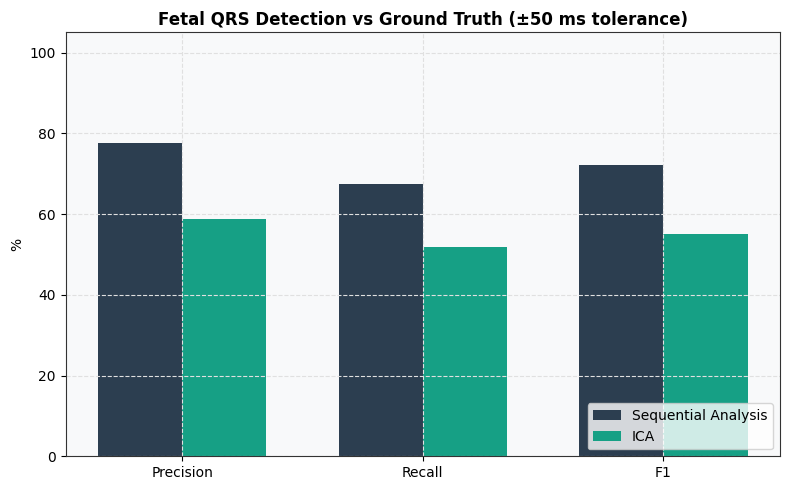

In [14]:
gt_tolerance_ms = 50.0
gt_tolerance = int((gt_tolerance_ms / 1000.0) * fs_target)

gt_results = []
for record_name, rec_data in all_records_data.items():
    sig, fs_rec = rec_data['signal'], rec_data['fs']
    gt_peaks_rec = load_ground_truth_peaks(data_dir, record_name, fs_target)

    s1 = sig
    s2 = np.zeros_like(s1)
    for ch in range(s1.shape[1]):
        s2[:, ch] = bwr.apply(s1[:, ch])
    s3 = np.zeros_like(s2)
    for ch in range(s2.shape[1]):
        s3[:, ch] = plc.apply(s2[:, ch])

    s4 = resampler.upsample(s3.T).T
    s5 = mecg_canc.apply(s4)
    peaks_sa = fecg_ext.detect_fetal_qrs(s5)

    ica_eval = FastICA(n_components=s4.shape[1], random_state=42, whiten='unit-variance')
    sources = ica_eval.fit_transform(s4)
    counts = [len(compute_fhr(fecg_ext.detect_fetal_qrs(sources[:, i].reshape(-1, 1)), fs_target))
              for i in range(sources.shape[1])]
    best = sources[:, int(np.argmax(counts))].reshape(-1, 1)
    peaks_ica = fecg_ext.detect_fetal_qrs(best)

    tp_sa, fp_sa, fn_sa = match_peaks_to_gt(peaks_sa, gt_peaks_rec, gt_tolerance)
    tp_ica, fp_ica, fn_ica = match_peaks_to_gt(peaks_ica, gt_peaks_rec, gt_tolerance)

    gt_results.append({
        'record': record_name, 'n_gt': len(gt_peaks_rec),
        'tp_sa': tp_sa, 'fp_sa': fp_sa, 'fn_sa': fn_sa,
        'tp_ica': tp_ica, 'fp_ica': fp_ica, 'fn_ica': fn_ica,
    })

df_gt = pd.DataFrame(gt_results)
prec_sa, rec_sa, f1_sa = precision_recall_f1(df_gt['tp_sa'].sum(), df_gt['fp_sa'].sum(), df_gt['fn_sa'].sum())
prec_ica, rec_ica, f1_ica = precision_recall_f1(df_gt['tp_ica'].sum(), df_gt['fp_ica'].sum(), df_gt['fn_ica'].sum())

print(f"Ground-truth validation over {len(df_gt)} records ({gt_tolerance_ms:.0f} ms tolerance)")
print(f"SA  -- precision: {prec_sa*100:.1f}%  recall: {rec_sa*100:.1f}%  F1: {f1_sa*100:.1f}%")
print(f"ICA -- precision: {prec_ica*100:.1f}%  recall: {rec_ica*100:.1f}%  F1: {f1_ica*100:.1f}%")

df_gt['recall_sa'] = df_gt['tp_sa'] / df_gt['n_gt']
worst_sa = df_gt.nsmallest(5, 'recall_sa')[['record', 'n_gt', 'tp_sa', 'fp_sa', 'fn_sa', 'recall_sa']]
print("\nLowest-recall records (SA):")
print(worst_sa.to_string(index=False))

plot_ground_truth_validation(prec_sa, rec_sa, f1_sa, prec_ica, rec_ica, f1_ica, gt_tolerance_ms)